## Decision Tree

Our goal is to predict the quarterly profit ($) of start up companies based on how much money they spend in Research and Development (R&D), Administration and Marketing, as well as the state the startup is in.

Here are what the columns represent:

- R&D Spend: How much money the company has spent on R&D
- Administration: How much money the company has spent on Administration (i.e., salaries)
- Marketing Spend: How much money the company has spent on Marketing
- State: The state the company is in (California, Florida or New York)
- Profit: The quarterly profit ($) amount the company has made.


## Data PreProcessing

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

**Read in the 50_startups.csv file and set it to a data frame called company_data.**

In [2]:
company_data = pd.read_csv('50_startups.csv')

**Check out the first couple of rows of the company_data**

In [3]:
company_data.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,64664.71,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


**Use info and describe() on company_data**

In [4]:
company_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [5]:
company_data.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73477.883200,121344.639600,211025.097800,112012.639200
std,46008.265809,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,33741.085000,103730.875000,129300.132500,90138.902500
50%,69820.065000,122699.795000,212716.240000,107978.190000
75%,100099.100000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


**Check out if there are any duplicates in the company_data**

In [6]:
company_data.duplicated().sum()

0

**Check out if there are any missing values in the company_data**

In [7]:
company_data.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

**Dummy variable creation (aka converting categorical columns into numerical)**

Based on the `info()` function, we know that there is one categorical column in our dataset: `state`. Depending on whether we think `state` is an important factor in predicting the profit of startups, we can either exclude the `state` column from our `X` data or convert it into a numerical column, called a dummy column. This conversion is essential because many machine learning algorithms require input data to be numeric.

For example, if you have a column called `Gender` with the categories `"Male"` and `"Female"`, we can convert it into a dummy column showing whether the gender is male or not.

| Gender  | Gender_Male |
|---------|------------|
| Male    |   1        |
| Female  |   0        |
| Female  | 0          |
| Male    | 1          |

The syntax for creating dummy variables in pandas is:

```python
dummy_column = pd.get_dummies(df, columns=['Gender'], drop_first=True)

Let's take a look at which states are in the data

In [8]:
company_data["State"].unique()

array(['New York', 'California', 'Florida'], dtype=object)

In [9]:
company_data2 = pd.get_dummies(company_data, columns=['State'], drop_first=True)

In [10]:
company_data2.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,64664.71,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False


## Train/Test Split

You'll have the freedom here to choose columns that you want to train on!

In [11]:
X = company_data2[['R&D Spend', 'Administration', 'Marketing Spend', 'State_Florida', 'State_New York']]
y = company_data2['Profit']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Algorithm Setup

In [13]:
from sklearn.tree import DecisionTreeRegressor

In [14]:
dtree = DecisionTreeRegressor(max_depth=3)

max_depth = 3 means the tree can make up to 3 decisions from the root to a leaf, limiting its complexity to ensure the model remains relatively interpretable.

## Model Training

In [15]:
dtree.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=3)

## Model Testing

In [16]:
predictions = dtree.predict(X_test)

## Evaluation

In [17]:
from sklearn import metrics

print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, predictions))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, predictions))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

Mean Absolute Error: 10983.889000000001
Mean Squared Error: 239454752.07706147
Root Mean Squared Error: 15474.325577454465


### Extra: Tree Visualization

In [18]:
print(dict(zip(X.columns, dtree.feature_importances_)))

{'R&D Spend': 0.6380770851668686, 'Administration': 0.0170380423651868, 'Marketing Spend': 0.34012210678337607, 'State_Florida': 0.004762765684568455, 'State_New York': 0.0}


In [19]:
from sklearn import tree
text_representation = tree.export_text(dtree)
print(text_representation)

|--- feature_0 <= 29526.23
|   |--- feature_0 <= 8410.60
|   |   |--- feature_3 <= 0.50
|   |   |   |--- value: [28620.57]
|   |   |--- feature_3 >  0.50
|   |   |   |--- value: [49490.75]
|   |--- feature_0 >  8410.60
|   |   |--- feature_2 <= 156235.91
|   |   |   |--- value: [68819.27]
|   |   |--- feature_2 >  156235.91
|   |   |   |--- value: [81994.00]
|--- feature_0 >  29526.23
|   |--- feature_2 <= 358022.59
|   |   |--- feature_2 <= 221897.88
|   |   |   |--- value: [105151.72]
|   |   |--- feature_2 >  221897.88
|   |   |   |--- value: [130490.15]
|   |--- feature_2 >  358022.59
|   |   |--- feature_1 <= 100480.13
|   |   |   |--- value: [161589.53]
|   |   |--- feature_1 >  100480.13
|   |   |   |--- value: [189501.57]



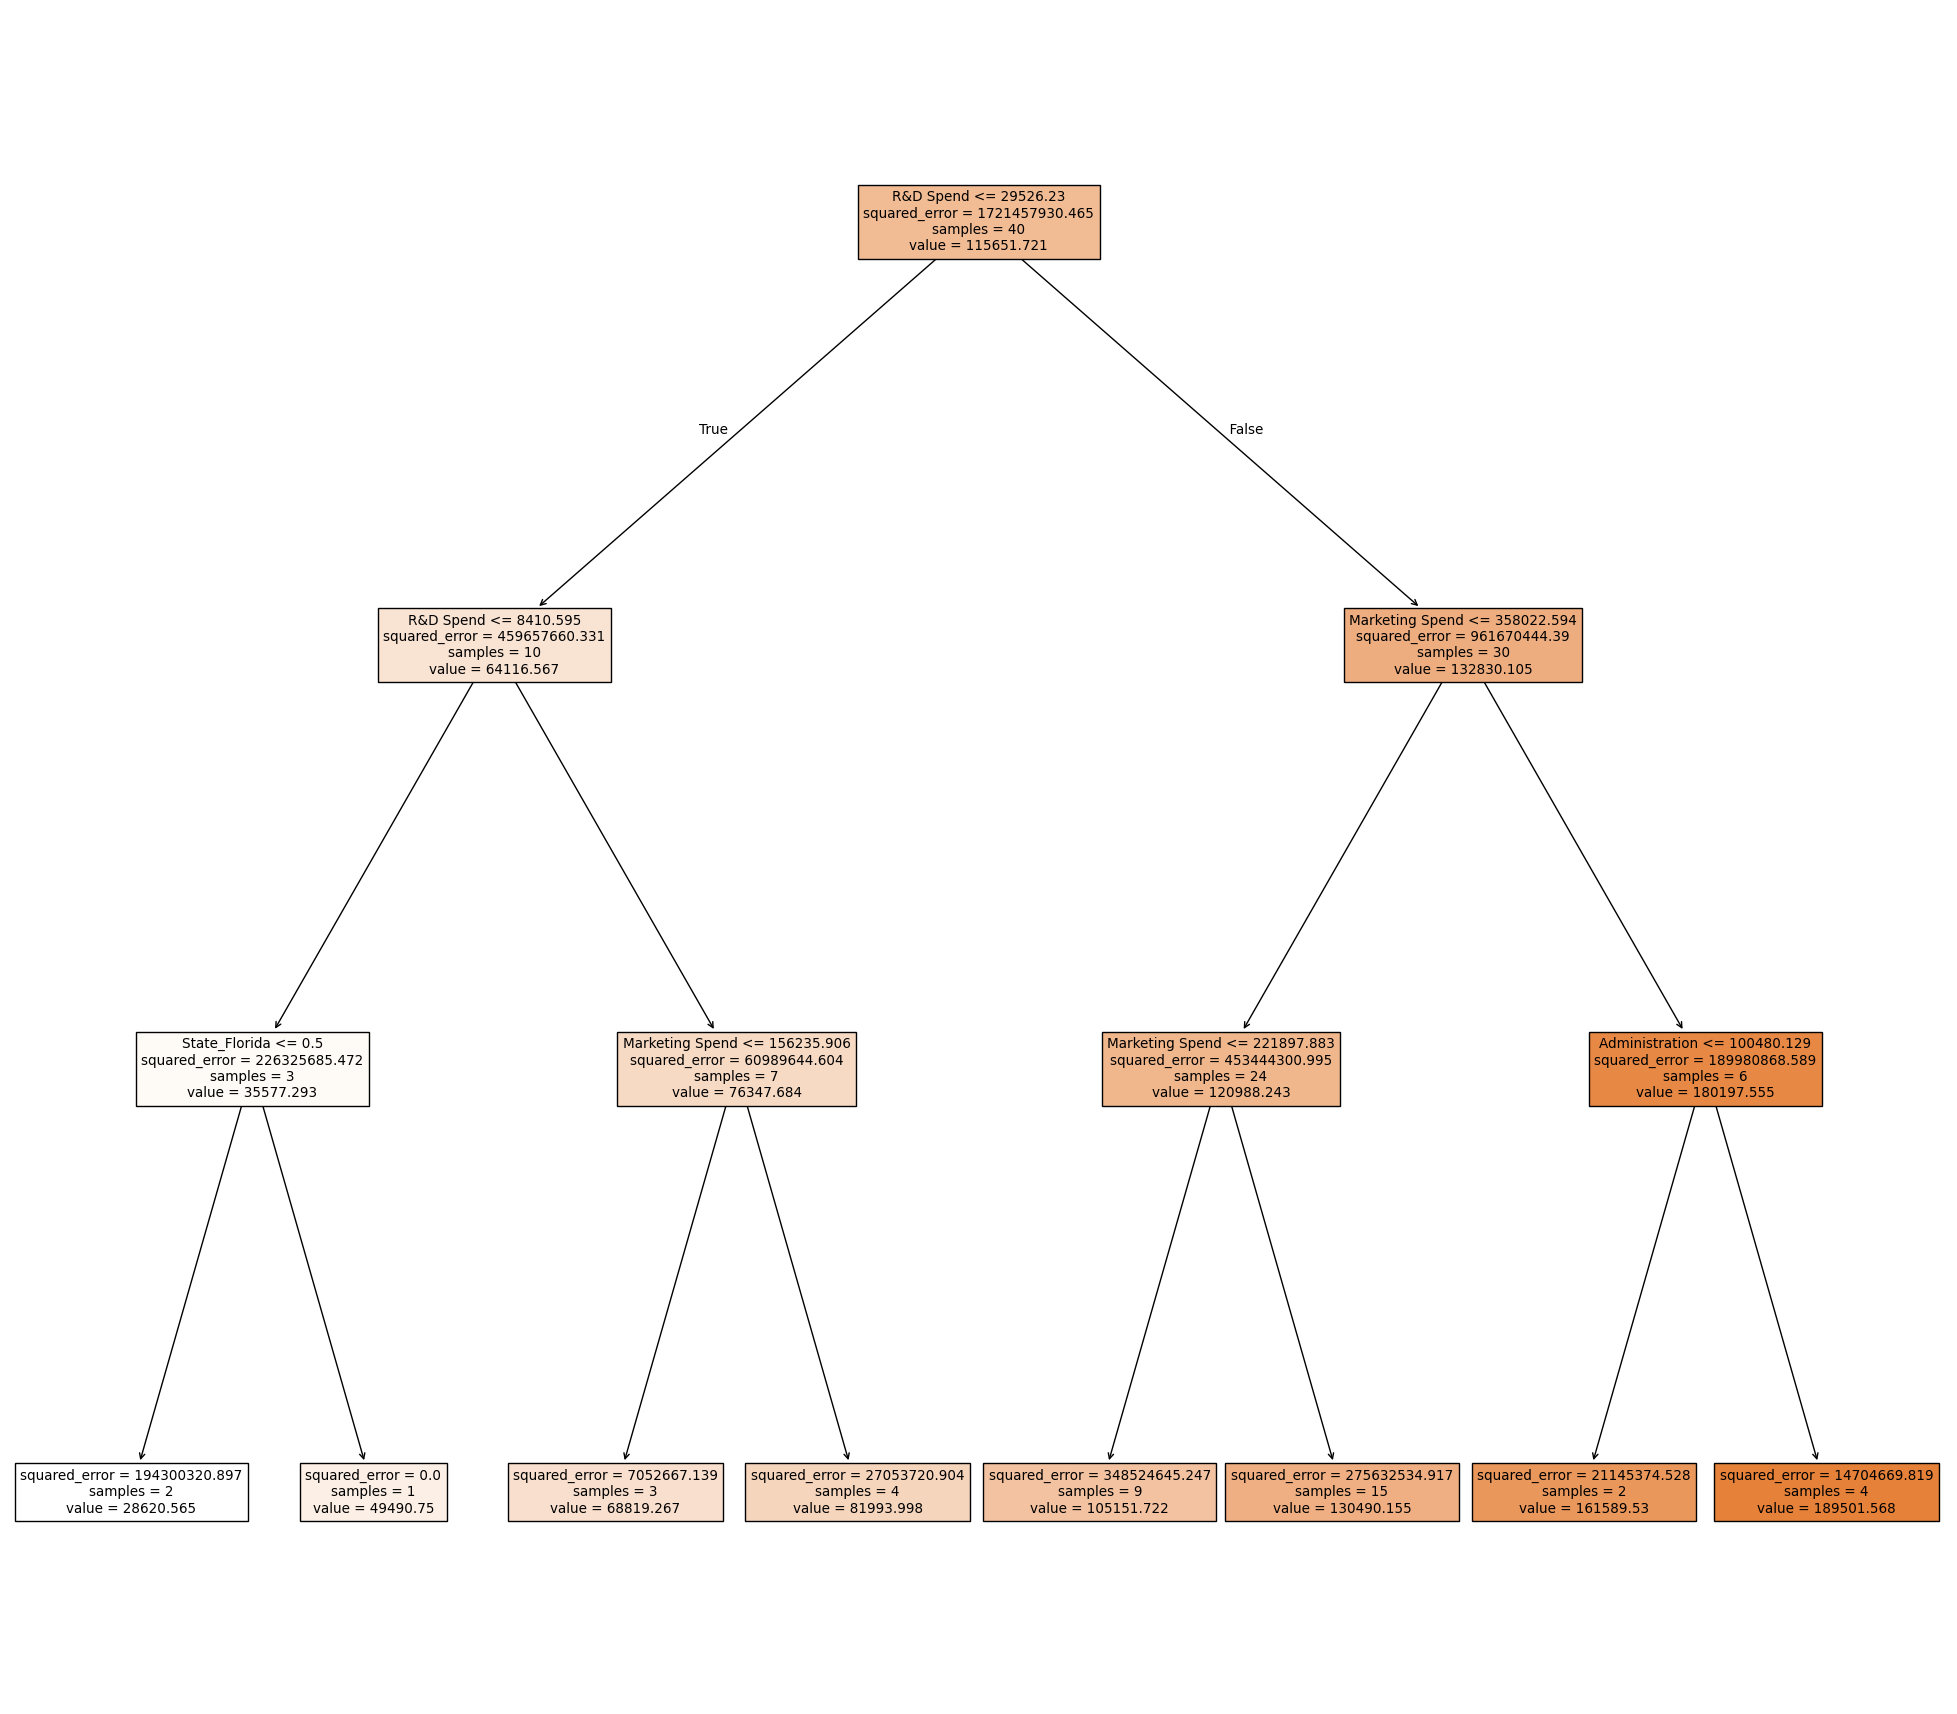

In [20]:
fig = plt.figure(figsize=(25,22))
_ = tree.plot_tree(dtree, 
                   feature_names=X_train.columns.tolist(),  
                   class_names=y_train.unique().tolist(),
                   filled=True)
plt.show()

### Algorithm Setup - Random Forest

Let's create an instance of the RandomForestRegressor and fit it to our training data. n_estimators show the number of trees to create!

In [21]:
from sklearn.ensemble import RandomForestRegressor

regressor = RandomForestRegressor(n_estimators=20, random_state=0)


### Random Forest Model Training

In [22]:
regressor.fit(X_train, y_train)

RandomForestRegressor(n_estimators=20, random_state=0)

### Random Forest Model Testing

In [23]:
y_pred = regressor.predict(X_test)

### Random Forest Model Evaluation

In [24]:
from sklearn import metrics

print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error: 14085.574499999999
Mean Squared Error: 383915576.68860614
Root Mean Squared Error: 19593.76371932167
